# Synthetic Control — Texas Prison Construction & Black Male Incarceration

Reads in the state-year panel and confirms the treated unit, donor pool, and time span
ahead of building the synthetic control (Cunningham, *Causal Inference: The Mixtape*).

| | |
|---|---|
| **Treatment** | Texas prison construction program |
| **Treated unit** | `Texas` |
| **Outcome** | `bmprate` — Black male incarceration rate |
| **Panel** | 51 U.S. states + D.C., 1985\u20132000 |
| **Reference weights** | ~0.409 California + 0.108 Florida + 0.361 Illinois + 0.122 Louisiana |
| **Dataset** | pysyncon replication data |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

In [2]:
df = pd.read_csv(Path("../data/raw/texas.csv"))

TREATED_UNIT = "Texas"

donor_pool = sorted(df.loc[df["state"] != TREATED_UNIT, "state"].unique().tolist())

print(f"Treated unit : {TREATED_UNIT}")
print(f"Donor states : {len(donor_pool)}")
print(f"Years        : {df['year'].min():.0f}\u2013{df['year'].max():.0f}")
print(f"Shape        : {df.shape}")
df.head()

Treated unit : Texas
Donor states : 50
Years        : 1985–2000
Shape        : (816, 24)


,statefip,year,race,bmprison,wmprison,bmpop,wmpop,error,crack,alcohol,...,perc1519,aidscapita,state,parole,probation,capacity_rated,capacity_operational,capacity_design,bmprate,wmprate
0,1.0,1985.0,2.0,6227.0,4210.0,464428,1427743,0.0,0.217438,1.90,...,8.461768,0.679504,Alabama,2425.0,16520,9787.0,9787.0,9787.0,1340.7891,294.87100
1,1.0,1986.0,1.0,6657.0,4423.0,465387,1434773,0.0,0.276875,1.90,...,8.473580,0.851692,Alabama,3038.0,21371,10374.0,10374.0,10374.0,1430.4224,308.27176
2,1.0,1987.0,1.0,7281.0,4803.0,467545,1442894,0.0,0.211371,1.89,...,8.397089,1.967214,Alabama,3456.0,23406,11107.0,11107.0,11107.0,1557.2832,332.87268
3,1.0,1988.0,1.0,7244.0,4605.0,468281,1445048,0.0,0.559781,1.89,...,8.280076,2.758137,Alabama,4701.0,25301,11162.0,11162.0,11162.0,1546.9344,318.67453
4,1.0,1989.0,1.0,8056.0,4998.0,468893,1445678,0.0,0.721824,1.87,...,8.088959,3.845907,Alabama,5724.0,25519,11162.0,11662.0,11662.0,1718.0892,345.72015


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   statefip              816 non-null    float64
 1   year                  816 non-null    float64
 2   race                  816 non-null    float64
 3   bmprison              816 non-null    float64
 4   wmprison              802 non-null    float64
 5   bmpop                 816 non-null    int64  
 6   wmpop                 816 non-null    int64  
 7   error                 816 non-null    float64
 8   crack                 816 non-null    float64
 9   alcohol               816 non-null    float64
 10  income                816 non-null    int64  
 11  ur                    816 non-null    float64
 12  poverty               816 non-null    float64
 13  black                 816 non-null    float64
 14  perc1519              816 non-null    float64
 15  aidscapita            816 non-null

In [4]:
print("Missing values per column:")
df.isnull().sum()

Missing values per column:


statefip                  0
year                      0
race                      0
bmprison                  0
wmprison                 14
bmpop                     0
wmpop                     0
error                     0
crack                     0
alcohol                   0
income                    0
ur                        0
poverty                   0
black                     0
perc1519                  0
aidscapita                0
state                     0
parole                    6
probation                 0
capacity_rated          287
capacity_operational    132
capacity_design         245
bmprate                   0
wmprate                  14
dtype: int64

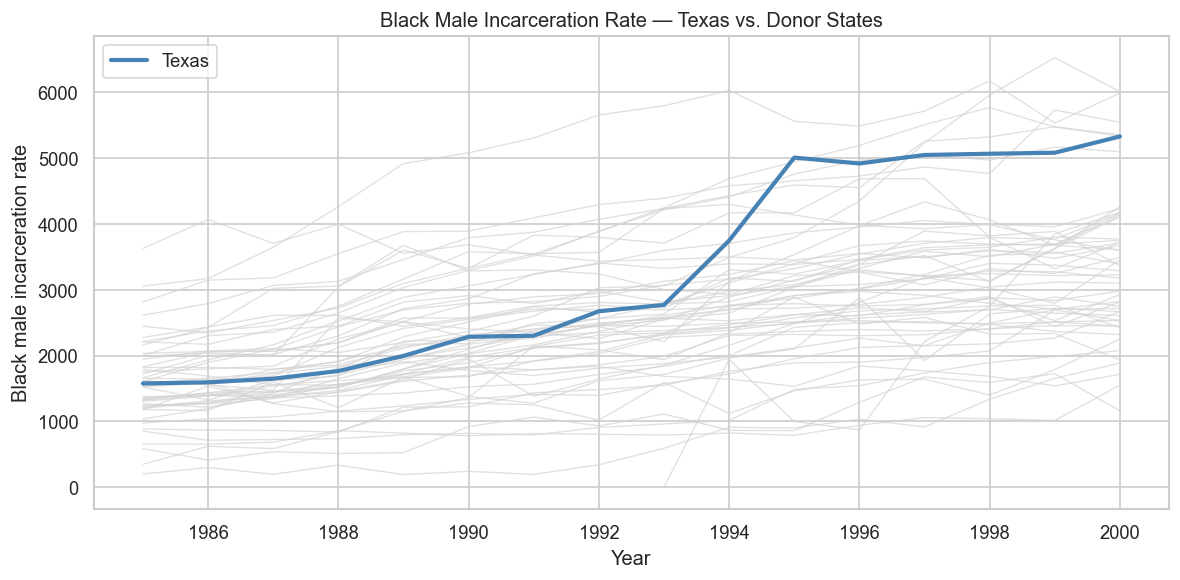

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

for state in donor_pool:
    s = df[df["state"] == state]
    ax.plot(s["year"], s["bmprate"], color="lightgrey", linewidth=0.8, alpha=0.7)

treated = df[df["state"] == TREATED_UNIT]
ax.plot(treated["year"], treated["bmprate"], color="steelblue", linewidth=2.5, label=TREATED_UNIT)
ax.set_xlabel("Year")
ax.set_ylabel("Black male incarceration rate")
ax.set_title("Black Male Incarceration Rate \u2014 Texas vs. Donor States")
ax.legend()
plt.tight_layout()
plt.show()